# FRBlip quick start

In [1]:
import numpy as np
import pandas as pd

import frblip as frb

import matplotlib.pyplot as plt

## Create a mock of Cosmic Bursts

In [2]:
#mock = frb.blips(random_state=42, duration=30, zmax=6, host_model=('LTG', 'YMW16'), spectral_index=0)

mock = frb.blips(random_state=42, duration=1, zmax=6, spectral_index=0)



get the redshift:

In [3]:
"""z = mock.redshift"""

mock.redshift

array([1.86119933, 5.42084138, 3.60063869, ..., 5.6904889 , 3.26764871,
       0.93128022])

Luminosity distance:

In [4]:
mock.luminosity_distance

<Quantity [14597.34387257, 52460.98520059, 32389.98036435, ...,
           55515.49404815, 28849.38064041,  6224.95488415] Mpc>

Dispersion mesuares:

In [5]:
mock.igm_dm
mock.host_dm
mock.extra_galactic_dm

"""DM_IGM = mock.igm_dm
DM_HG = mock.host_dm
DM_EG = mock.extra_galactic_dm"""

'DM_IGM = mock.igm_dm\nDM_HG = mock.host_dm\nDM_EG = mock.extra_galactic_dm'

Note that frblip uses units from astropy package

possible quantities and methods:

In [6]:
mock.__dict__.keys()

dict_keys(['duration', 'zmin', 'zmax', 'log_L0', 'log_Lstar', 'phistar', 'gamma', 'w_mean', 'w_std', '_spec_idx_dist', 'ra_range', 'dec_range', 'low_frequency', 'high_frequency', 'low_frequency_cal', 'high_frequency_cal', 'igm_model', 'free_electron_bias', 'cosmology', 'host_dist', 'host_source', 'host_model', 'emission_frame', 'start', 'gal_nside', 'gal_method', 'random_state', 'area', '_xmin', '_lumdist', '_cosmology', '_zdist', 'sky_rate', 'size', 'rate', 'params', 'spectral_index', 'redshift', 'luminosity_distance', 'log_luminosity', '_luminosity', 'flux', '_energy_normalization', '_igm_dm', 'igm_dm', '_host_dm', 'host_dm', 'extra_galactic_dm'])

Load a Radio Telescope:

In [7]:
input_main_name   = 'bingo'
input_array_name  = 'mirror_6m'

telescopes = {}

#main = frb.telescope(input_main_name)

telescopes['MAIN'] = frb.telescope(input_main_name)
telescopes['ARRAY'] = frb.telescope(input_array_name)

Perform observations on a mock

In [8]:
#mock.observe(bingo)
"""mock.observe(telescopes, verbose = False)
mock.interferometry('MAIN', 'ARRAY')"""

import pymp

# Defina uma função para cada operação que deseja paralelizar
def run_observe():
    mock.observe(telescopes, verbose=False)

# Use pymp para paralelizar as execuções
with pymp.Parallel(6) as p:
    run_observe()

In [9]:
def run_interferometry():
    mock.interferometry('MAIN', 'ARRAY')

# Use pymp para paralelizar as execuções
with pymp.Parallel(4) as p:
    run_interferometry()

The results are storage on observations property:

In [10]:
mock.observations

{'MAIN': <frblip.observation.Observation at 0x7f4d98f3de10>,
 'ARRAY': <frblip.observation.Observation at 0x7f4d98f3e5f0>,
 'INTF_MAIN_ARRAY': <frblip.observation.Interferometry at 0x7f4d98fb6860>}

Computing signal to noise ratio:

In [11]:
#mock.signal_to_noise()

Note that the information is given as a sparse array. To convert it you must pass True to `todense` argument:

In [12]:
#mock.signal_to_noise(todense=True)

To compute the total value over beams we pass True to the `total` argument

In [13]:
mock.signal_to_noise(total=True, todense=True)

{'MAIN': <xarray.DataArray (FRB: 74209)>
 array([0., 0., 0., ..., 0., 0., 0.])
 Dimensions without coordinates: FRB,
 'ARRAY': <xarray.DataArray (FRB: 74209)>
 array([1.99596169e-154, 0.00000000e+000, 0.00000000e+000, ...,
        0.00000000e+000, 6.29399700e-039, 0.00000000e+000])
 Dimensions without coordinates: FRB,
 'INTF_MAIN_ARRAY': <xarray.DataArray (FRB: 74209)>
 array([0., 0., 0., ..., 0., 0., 0.])
 Dimensions without coordinates: FRB}

The function `triggers` returns if a FRB is observed given minima signal to noise values, default value is range(1, 11):

In [14]:
#mock.triggers(todense=True)

In [15]:
mock.triggers(todense=True, total=True, snr=range(5, 16))

{'MAIN': <xarray.DataArray (FRB: 74209, SNR: 11)>
 array([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]])
 Coordinates:
   * SNR      (SNR) int64 5 6 7 8 9 10 11 12 13 14 15
 Dimensions without coordinates: FRB,
 'ARRAY': <xarray.DataArray (FRB: 74209, SNR: 11)>
 array([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]])
 Coordinates:
   * SNR      (SNR) int64 5 6 7 8 9 10 11 12 13 14 15
 Dimensions w

`counts` method returns the number of observed FRB:

In [16]:
#mock.counts()

In [17]:
#mock.counts(total=True)

In [18]:
mock.counts(total=True, snr=range(5, 16))

{'MAIN': <xarray.DataArray (SNR: 11)>
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
 Coordinates:
   * SNR      (SNR) int64 5 6 7 8 9 10 11 12 13 14 15,
 'ARRAY': <xarray.DataArray (SNR: 11)>
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
 Coordinates:
   * SNR      (SNR) int64 5 6 7 8 9 10 11 12 13 14 15,
 'INTF_MAIN_ARRAY': <xarray.DataArray (SNR: 11)>
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
 Coordinates:
   * SNR      (SNR) int64 5 6 7 8 9 10 11 12 13 14 15}

In [19]:
frb_data = mock.catalog()

/home/lazarolima/.conda/envs/env_frblip/lib/python3.10/site-packages/xarray/core/concat.py:504: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


In [20]:
len(frb_data['redshift'])

2

In [21]:
z = frb_data['redshift']
DM_IGM = frb_data['igm_dm']
DM_EG = frb_data['extra_galactic_dm']
DM_HG = frb_data['host_dm']

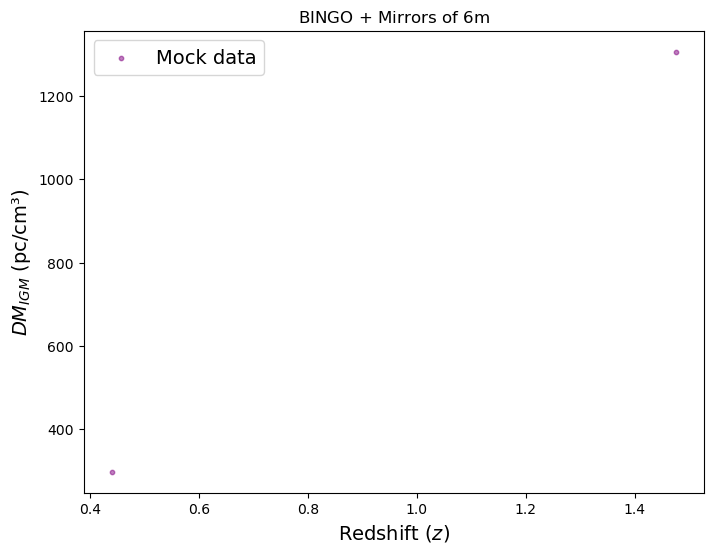

In [22]:
# Plot para o DM_IGM
plt.figure(figsize=(8, 6))
plt.scatter(z, DM_IGM, color='purple', alpha=0.5, label='Mock data', marker='o', s=10)
plt.xlabel('Redshift ($z$)', fontsize=14)
plt.ylabel('$DM_{IGM}$ (pc/cm³)', fontsize=14)
plt.title(label='BINGO $+$ Mirrors of 6m')
plt.legend(fontsize=14)
#plt.xlim(xmax=1)
#plt.ylim(ymax=1500)
plt.grid(False)
plt.savefig('mock_DM_IGM_bingo+mirror_6m.png', dpi=600)
plt.show()

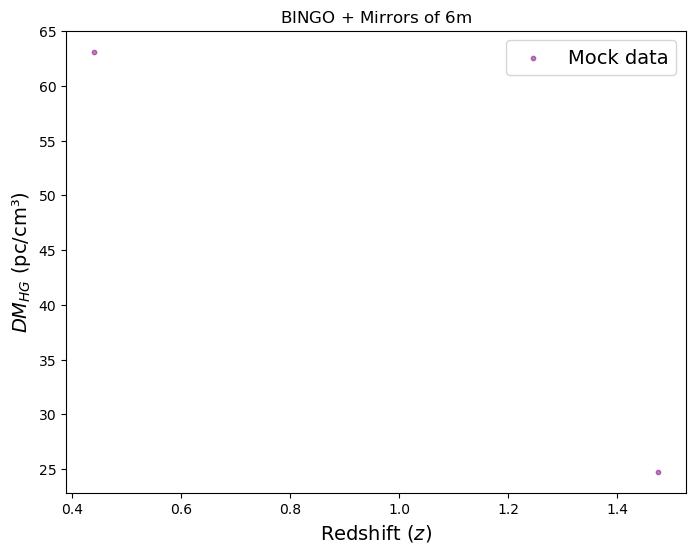

In [23]:
# Plot para o DM_HG
plt.figure(figsize=(8, 6))
plt.scatter(z, DM_HG, color='purple', alpha=0.5, label='Mock data', marker='o', s=10)
plt.xlabel('Redshift ($z$)', fontsize=14)
plt.ylabel('$DM_{HG}$ (pc/cm³)', fontsize=14)
plt.title(label='BINGO $+$ Mirrors of 6m')
plt.legend(fontsize=14)
#plt.xlim(xmax=1)
#plt.ylim(ymax=1500)
plt.grid(False)
plt.savefig('mock_DM_HG_bingo+mirror_6m.png', dpi=600)
plt.show()

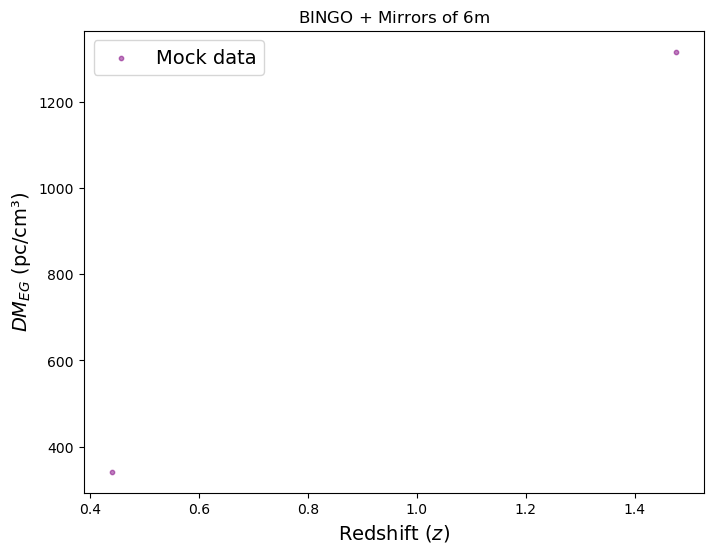

In [24]:
# Plot para o DM_EG
plt.figure(figsize=(8, 6))
plt.scatter(z, DM_EG, color='purple', alpha=0.5, label='Mock data', marker='o', s=10)
plt.xlabel('Redshift ($z$)', fontsize=14)
plt.ylabel('$DM_{EG}$ (pc/cm³)', fontsize=14)
plt.title(label='BINGO $+$ Mirrors of 6m')
plt.legend(fontsize=14)
#plt.xlim(xmax=1)
#plt.ylim(ymax=1500)
plt.grid(False)
plt.savefig('mock_DM_EG_bingo+mirror_6m.png', dpi=600)
plt.show()

In [25]:
# Salvando os dados da DM_IGM

# Removendo as unidades
DM_IGM_value = DM_IGM.to_value()  

# Combinando os arrays em duas colunas
data = np.column_stack((z, DM_IGM_value))
np.savetxt('data_sim/DM_IGM_sim_bingo+mirror_6m.txt', data, fmt='%f', delimiter='\t', header='z\tDM_IGM')

In [26]:
# Salvando os dados da DM_EG
DM_EG_value = DM_EG.to_value()  
data = np.column_stack((z, DM_EG_value))
np.savetxt('data_sim/DM_EG_sim_bingo+mirror_6m.txt', data, fmt='%f', delimiter='\t', header='z\tDM_EG')

In [27]:
# Salvando os dados da DM_HG
DM_EG_value = DM_HG.to_value() 
data = np.column_stack((z, DM_EG_value))
np.savetxt('data_sim/DM_HG_sim_bingo+mirror_6m.txt', data, fmt='%f', delimiter='\t', header='z\tDM_HG')

In [28]:
from astropy.coordinates import SkyCoord
from astropy.visualization import astropy_mpl_style
import astropy.units as u

plt.style.use(astropy_mpl_style)


In [29]:
declination = frb_data['declination']
right_ascension = frb_data['right_ascension']

coords = SkyCoord(ra=right_ascension, dec=declination, frame='icrs')


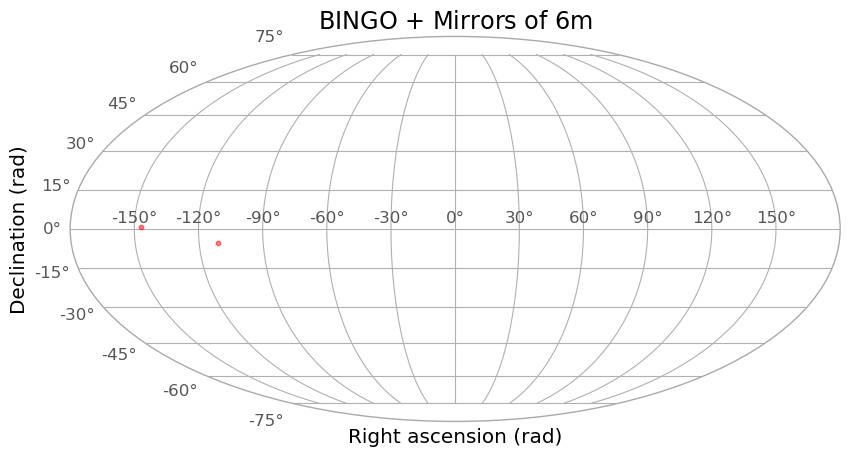

In [30]:
plt.figure(figsize=(10, 5))
plt.subplot(111, projection="mollweide")

# Converter RA para radianos e ajustar para o formato da projeção
ra_rad = coords.ra.wrap_at(180 * u.deg).radian
dec_rad = coords.dec.radian

plt.scatter(ra_rad, dec_rad, color='red', marker='o', s=10, alpha=0.5)
plt.grid(True)

plt.xlabel('Right ascension (rad)')
plt.ylabel('Declination (rad)')
plt.title(label='BINGO $+$ Mirrors of 6m')
plt.savefig('sky_map_bingo+mirror_6m.png', dpi=600)
plt.show()

In [31]:
import joblib

data = joblib.load('/home/lazarolima/frblip/frblip/data/bingo.pkl')
print(data)


{'az': <Quantity [148.76078511, 163.56583679, 198.14557866, 214.58397169,
           131.66614934, 143.65254179, 229.76364169, 235.46917426,
            95.76263289,  51.1701751 , 323.29714497, 275.76263289,
            55.25119875,  18.71858898, 344.00169942, 311.72951208,
            33.92979742,  11.09889925, 349.93543179, 329.30735712,
            23.68875157,   7.80791767, 352.72125828, 338.16293664,
            17.93236716,   6.07871824, 354.24759531, 343.37278965] deg>, 'alt': <Quantity [84.66627546, 86.39138556, 86.88227317, 85.12789316, 86.36669439,
           88.36233119, 88.72860972, 86.70575604, 87.27281998, 88.69021291,
           88.29268668, 87.27281998, 86.63640333, 86.81922624, 86.29561336,
           86.29628393, 85.04531914, 84.69249541, 84.15176962, 84.58054728,
           83.10842769, 82.46833941, 81.92054222, 82.55330907, 80.99185793,
           80.31943396, 79.76656596, 80.47714821] deg>, 'lat': <Quantity -7.041 deg>, 'lon': <Quantity -38.268 deg>, 'height': <Qua